# Эксперимент: Готовность router-слоя

**Цель.** Проверить, что reference-layer для posterior-based Gaussian router физически согласован и пригоден для классификации.

**Исследовательские вопросы.**
- Достаточно ли объектов в каждом `router_label`?
- Хорошо ли обусловлены ковариации после shrinkage/stabilization?
- Насколько часто объекты собственного класса выигрывают по posterior у конкурирующих классов?

**Что считается готовым результатом.**
- Построена таблица готовности с posterior-aware метриками.
- Сохранены канонические CSV-артефакты.
- Есть минимальный набор графиков для визуального аудита router-layer.


## Источники данных и артефакты

Этот ноутбук опирается на `analysis.router_eda`.

**Входной источник.**
- `lab.v_gaia_router_training`

**Ключевые выходы.**
- `data/eda/router/router_class_counts.csv`
- `data/eda/router/router_gaussian_readiness.csv`
- PNG-графики в `data/eda/router/plots/`


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Repo root with src/ not found.')
    REPO_ROOT = REPO_ROOT.parent

SRC_ROOT = REPO_ROOT / 'src'
for path in (REPO_ROOT, SRC_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from IPython.display import Image, display
import pandas as pd

from analysis.router_eda.constants import CLASS_COUNTS_PATH, GAUSS_STATS_PATH, PLOTS_DIR
from analysis.router_eda.data import (
    build_class_counts,
    build_router_training_query,
    ensure_router_labels,
    make_engine_from_env,
    read_sql_frame,
)
from analysis.router_eda.exports import save_router_artifacts
from analysis.router_eda.plots import (
    plot_router_correlation_heatmaps,
    plot_router_feature_histograms,
    plot_router_label_counts,
    plot_router_scatter,
    set_default_theme,
)
from analysis.router_eda.readiness import calc_router_gauss_stats

set_default_theme()
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)


## План анализа

1. Загрузить референсный слой router и сформировать `router_label`.
2. Посчитать размеры классов и метрики готовности.
3. Сохранить canonical CSV-артефакты.
4. Построить базовые графики для визуального контроля.


In [2]:
engine = make_engine_from_env()
df_router = ensure_router_labels(read_sql_frame(engine, build_router_training_query()))
counts = build_class_counts(df_router)
gauss_stats = calc_router_gauss_stats(df_router)
save_router_artifacts(df_router, counts, gauss_stats)

print(df_router.shape)
display(counts)


(39413, 7)


,spec_class,evolution_stage,router_label,n_objects
0,A,dwarf,A_dwarf,2097
1,A,evolved,A_evolved,3000
2,B,dwarf,B_dwarf,1975
3,B,evolved,B_evolved,3000
4,F,dwarf,F_dwarf,3000
5,F,evolved,F_evolved,3000
6,G,dwarf,G_dwarf,3000
7,G,evolved,G_evolved,3000
8,K,dwarf,K_dwarf,3000
9,K,evolved,K_evolved,3000


## Таблица готовности

Для router-layer важны не только размеры классов, но и posterior-устойчивость. Поэтому здесь смотрим на `log_det_cov`, `cond_effective_cov`, `self_posterior_win_rate` и `self_posterior_margin_mean`.


In [3]:
preview = gauss_stats[
    [
        'router_label',
        'n_objects',
        'log_det_cov',
        'cond_effective_cov',
        'pd_effective_cov',
        'self_posterior_win_rate',
        'self_posterior_margin_mean',
    ]
].sort_values('router_label')
preview


,router_label,n_objects,log_det_cov,cond_effective_cov,pd_effective_cov,self_posterior_win_rate,self_posterior_margin_mean
0,A_dwarf,2097,-19.517364,901.871073,True,0.986171,2.510703
1,A_evolved,3000,-14.231355,45.657653,True,0.873333,2.275982
2,B_dwarf,1975,-15.096185,1602.045653,True,0.885570,6.314038
3,B_evolved,3000,-9.578041,8.754395,True,0.742667,8.241338
4,F_dwarf,3000,-20.696130,1340.853474,True,0.969000,3.214315
5,F_evolved,3000,-12.354008,80.884604,True,0.710333,1.576179
6,G_dwarf,3000,-22.175230,2307.165709,True,0.940667,2.237072
7,G_evolved,3000,-14.743313,228.213405,True,0.962667,2.474075
8,K_dwarf,3000,-21.052629,3068.143929,True,0.865667,3.588595
9,K_evolved,3000,-12.705161,877.739549,True,0.876667,3.405104


In [4]:
print('Сохранён canonical class counts:', CLASS_COUNTS_PATH)
print('Сохранён canonical readiness:', GAUSS_STATS_PATH)


Сохранён canonical class counts: data/eda/router/router_class_counts.csv
Сохранён canonical readiness: data/eda/router/router_gaussian_readiness.csv


## Ключевые визуализации

Здесь достаточно компактного набора графиков: состав классов, одно feature-distribution, одна физическая проекция и heatmap корреляций.


data/eda/router/plots/router_class_stage_counts.png


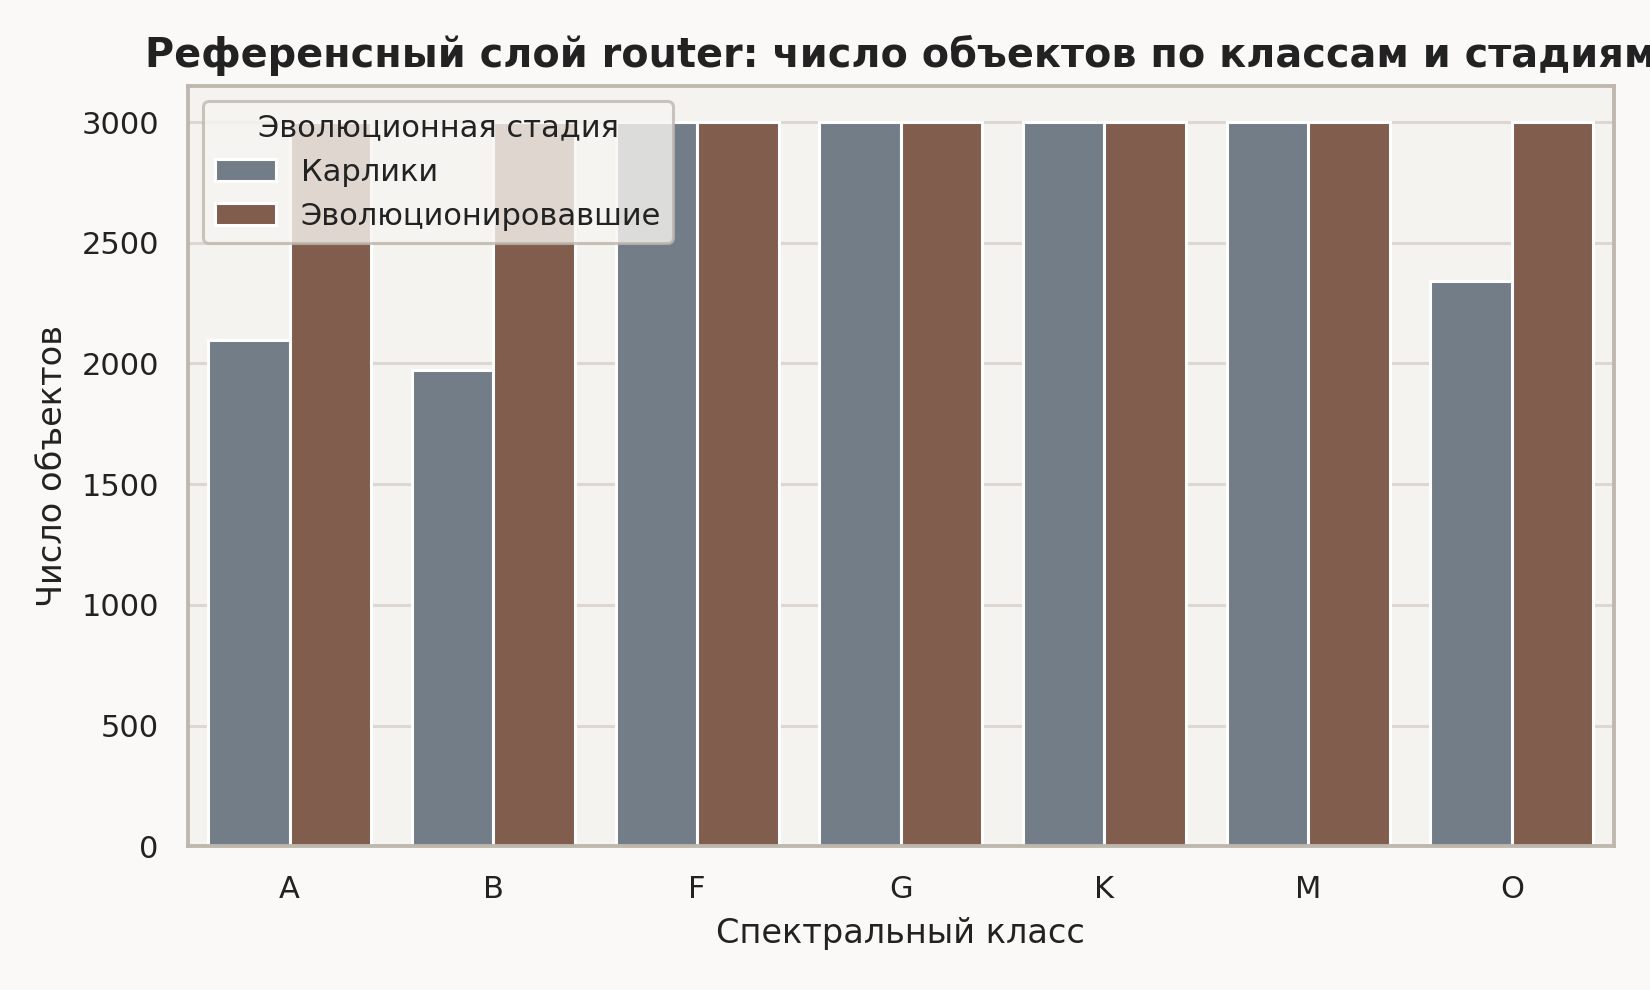

data/eda/router/plots/router_teff_gspphot_hist.png


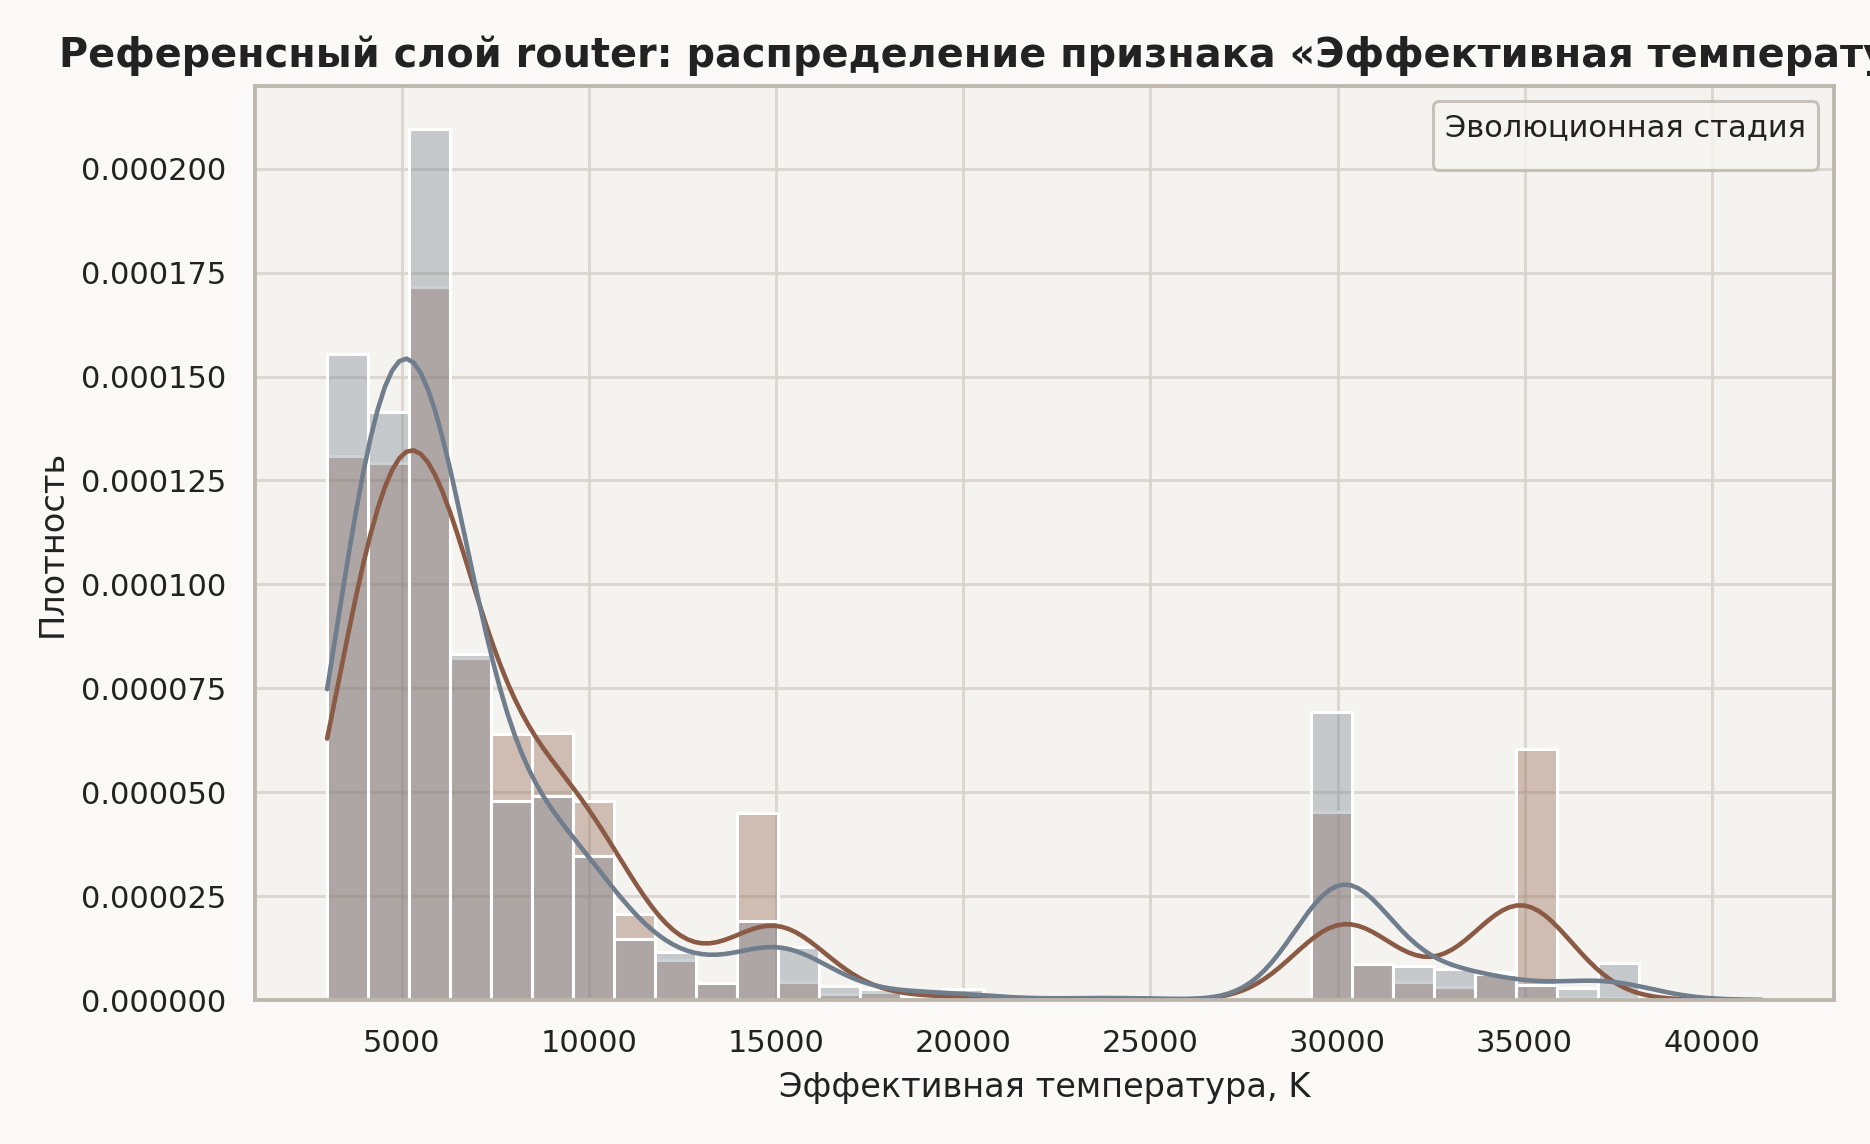

data/eda/router/plots/router_teff_vs_logg_scatter.png


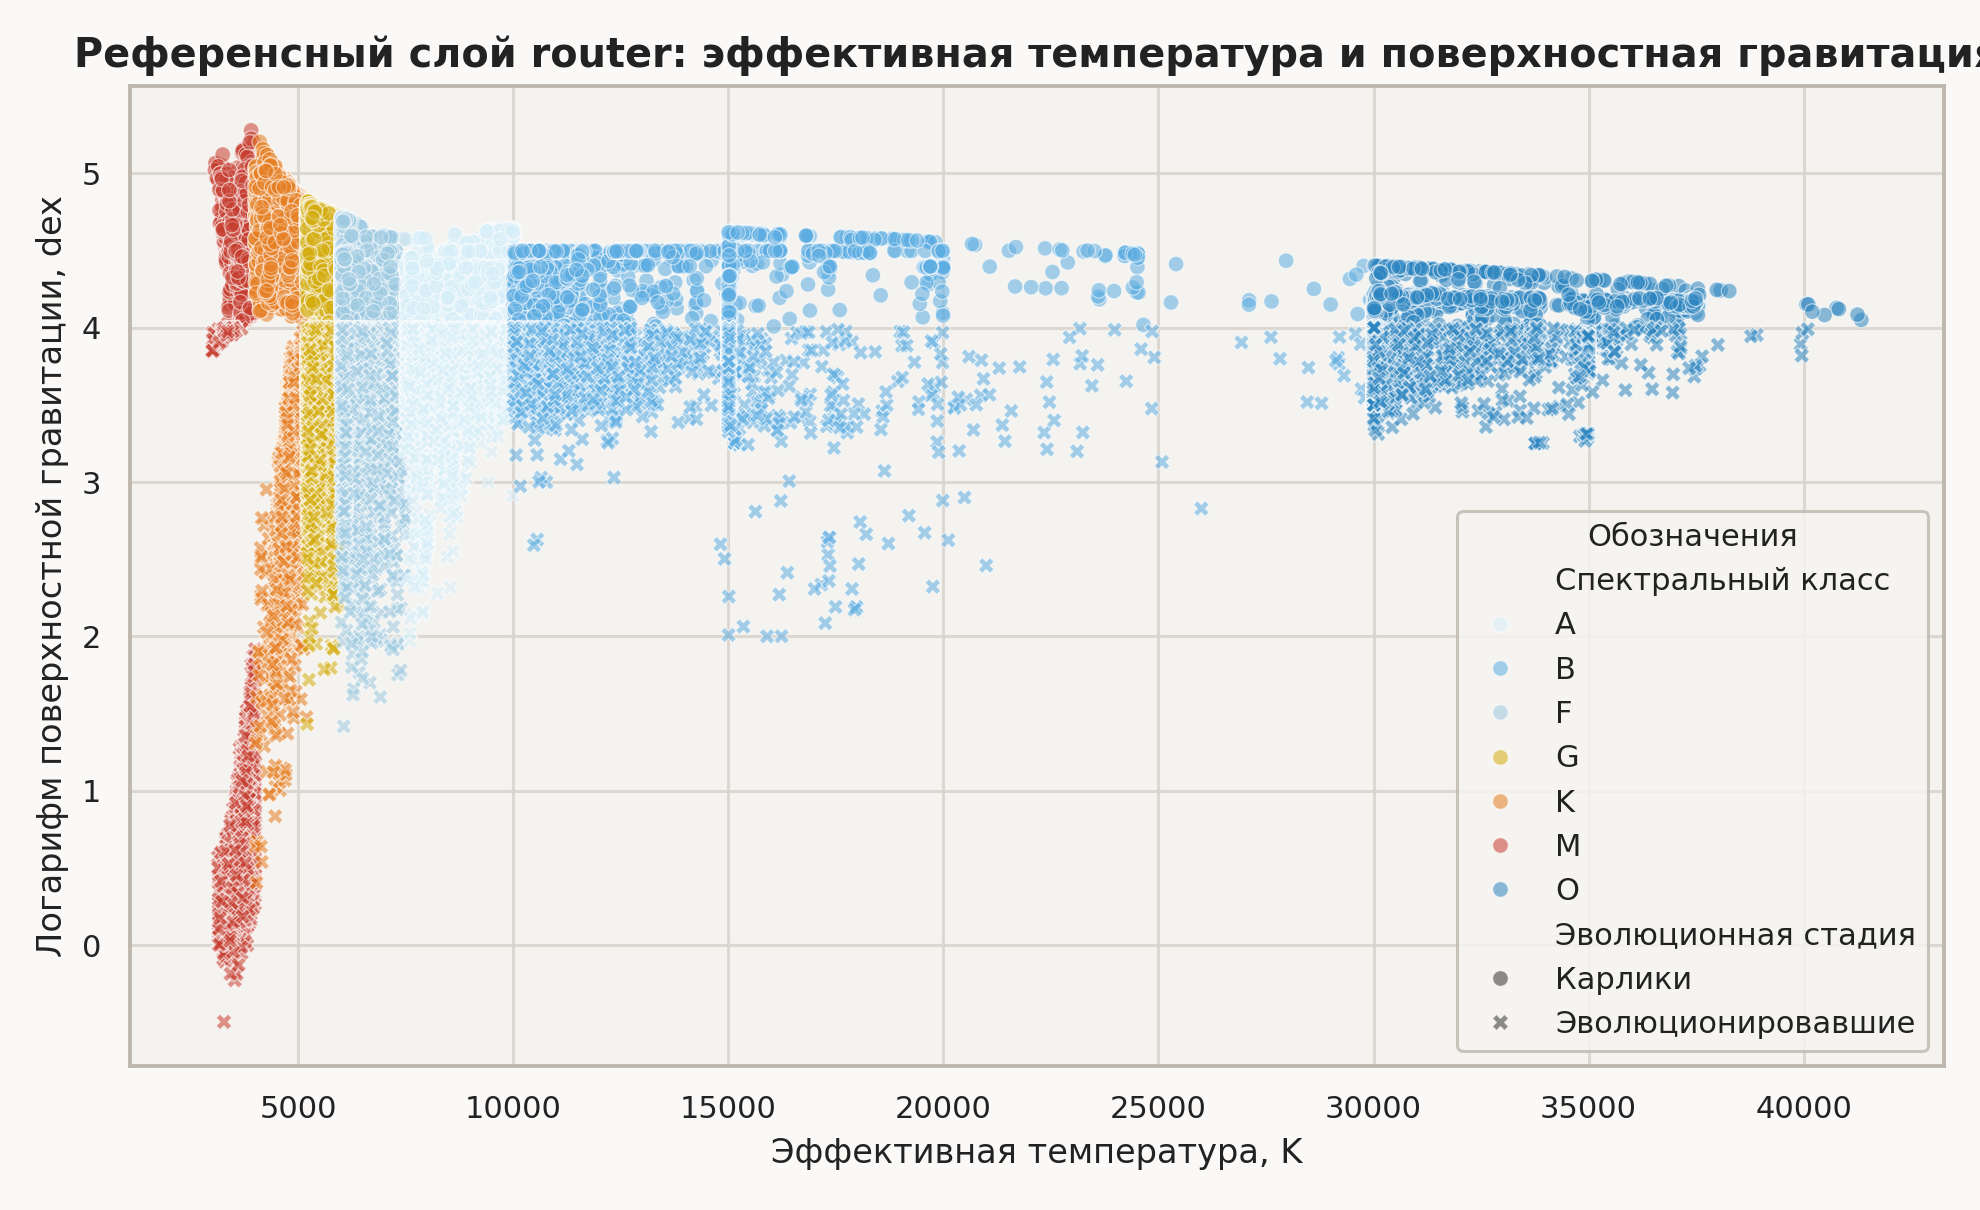

data/eda/router/plots/router_corr_heatmaps_all_dwarfs_evolved.png


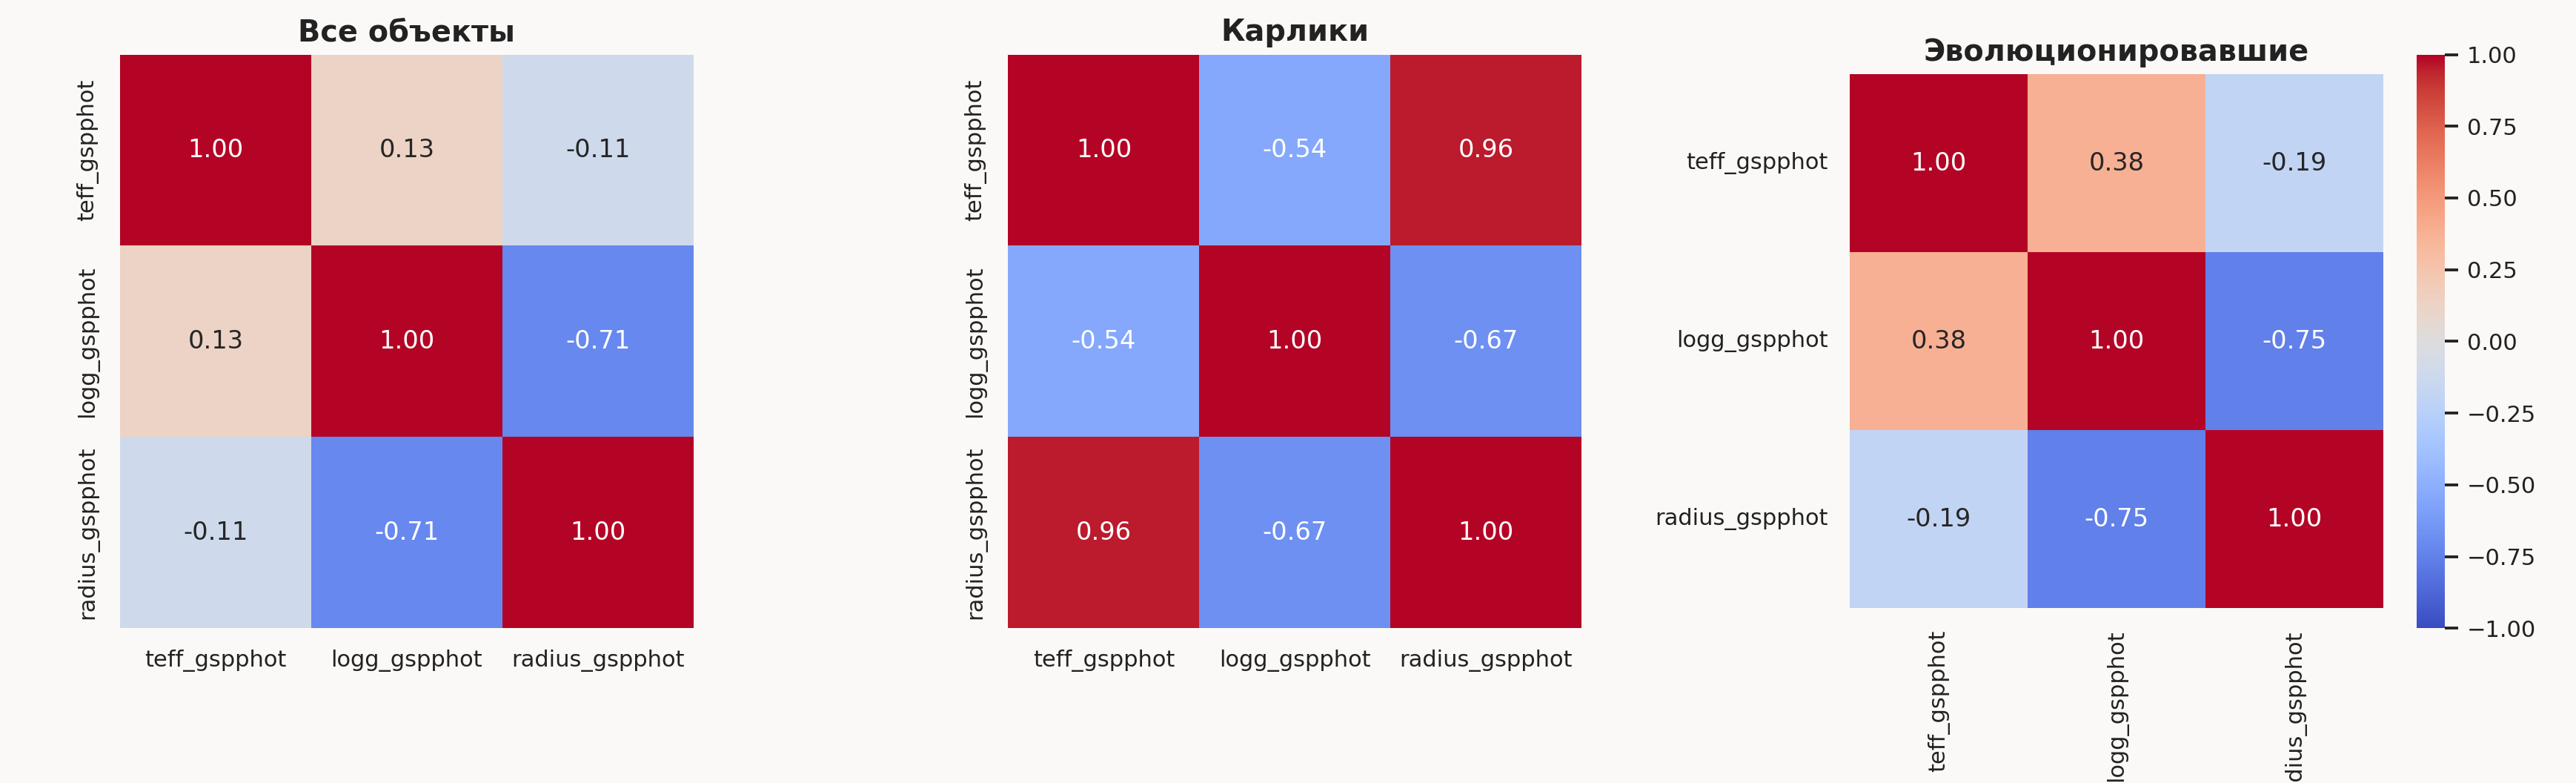

In [5]:
plot_router_label_counts(df_router)
plot_router_feature_histograms(df_router)
plot_router_scatter(
    df_router,
    x='teff_gspphot',
    y='logg_gspphot',
    filename='router_teff_vs_logg_scatter.png',
    title='Референсный слой router: эффективная температура и поверхностная гравитация',
)
plot_router_correlation_heatmaps(df_router)

for filename in [
    'router_class_stage_counts.png',
    'router_teff_gspphot_hist.png',
    'router_teff_vs_logg_scatter.png',
    'router_corr_heatmaps_all_dwarfs_evolved.png',
]:
    path = PLOTS_DIR / filename
    print(path)
    display(Image(filename=path))


## Интерпретация

При разборе результатов стоит обратить внимание на следующее:
- низкий `self_posterior_win_rate` у конкретного класса означает физическое смешение reference-layer;
- высокий `cond_effective_cov` указывает на плохо обусловленную ковариацию даже после shrinkage;
- отрицательные или близкие к нулю margins означают, что класс плохо отделяется от соседних веток.

Эти наблюдения напрямую влияют на то, насколько надёжен текущий router в production pipeline.


## Следующий шаг

После аудита готовности router-слоя можно переходить к анализу `host vs field` и проверять разделимость уже внутри физически распознанных веток.
